# step 8: Exploratory Data Analysis

Bring the required data from SQL into Python and perform:

●	Univariate analysis

●	Bivariate analysis

●	Multivariate analysis

●	Trend analysis

●	Correlation analysis

●	Distribution analysis



In this step, the required data is retrieved from the MySQL database and analyzed using univariate, bivariate, multivariate, trend, correlation, and distribution analysis.

# Step 1:- Import libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
from getpass import getpass

In [10]:
from getpass import getpass

# 2.Connect Python to MySQL

In [11]:
import mysql.connector

conn_mysql = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Rg1815$$"

)

cursor_mysql = conn_mysql.cursor()
print("MySQL connection established!")

MySQL connection established!


# select your project database.

In [12]:
cursor_mysql.execute("USE Cart2insight_db;")

print("Database selected!")

Database selected!


# Python is now using your Cart2insight_db database.

In [13]:
cursor_mysql.execute("SELECT DATABASE();")
print(cursor_mysql.fetchone())

('cart2insight_db',)


In [14]:
cursor_mysql.execute("SELECT * FROM orders;")

rows = cursor_mysql.fetchall()
columns = [col[0] for col in cursor_mysql.description]

orders = pd.DataFrame(rows, columns=columns)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17


## 1. Univariate Analysis

Analyze one variable at a time to understand its frequency, distribution, and basic pattern.

order_status.

In [ ]:
# orders["order_status"].value_counts()
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

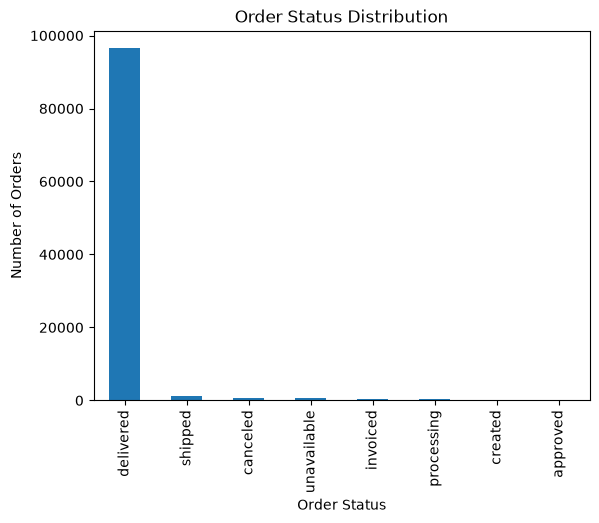

In [17]:
orders["order_status"].value_counts().plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

## 1. Univariate Analysis

### Question 1: What is the distribution of order statuses?


orders["order_status"].value_counts()


bar chart code

# 2: Review Score Distribution.

2: What is the distribution of review scores?


In [18]:
cursor_mysql.execute("SELECT * FROM reviews;")

rows = cursor_mysql.fetchall()
columns = [col[0] for col in cursor_mysql.description]

reviews = pd.DataFrame(rows, columns=columns)

In [ ]:
# check scorer
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

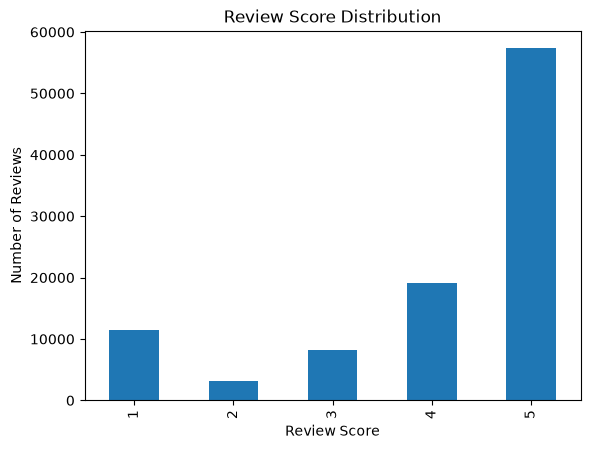

In [20]:
reviews["review_score"].value_counts().sort_index().plot(kind="bar")

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.show()


3. How many customers gave 1-star, 2-star, 3-star, 4-star, and 5-star reviews?

# 3: Payment Type Distribution.

#Question 3: What is the distribution of payment types?

In [21]:
cursor_mysql.execute("SELECT * FROM payments;")

rows = cursor_mysql.fetchall()
columns = [col[0] for col in cursor_mysql.description]

payments = pd.DataFrame(rows, columns=columns)

In [22]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

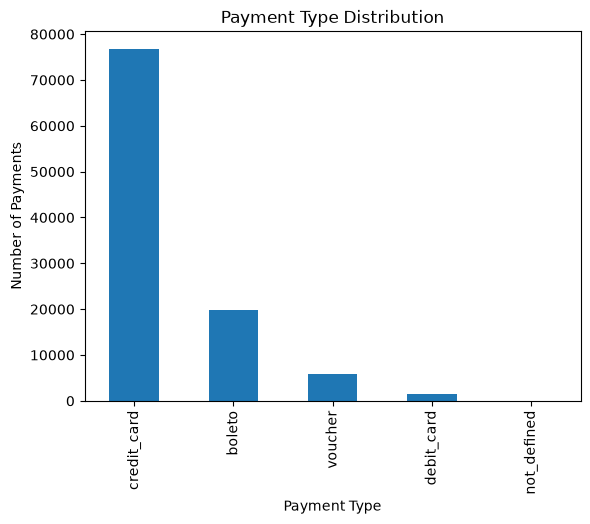

In [23]:
payments["payment_type"].value_counts().plot(kind="bar")

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.show()

3: Which payment type is used the most by customers?

Which payment method is most commonly used?

What is the most popular payment type?

Which payment type has the highest number of transactions?


# 2. Bivariate Analysis

Analyze the relationship between two variables.

### Question 1: Which payment type has the highest average payment value?

In [24]:
avg_payment = (
    payments
    .groupby("payment_type")["payment_value"]
    .mean()
    .sort_values(ascending=False)
)

avg_payment

payment_type
credit_card    163.319021
boleto         145.034435
debit_card      142.57017
voucher         65.703354
not_defined           0.0
Name: payment_value, dtype: object

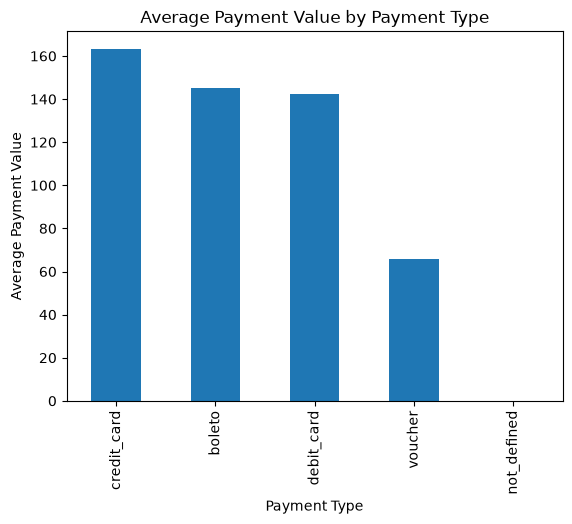

In [25]:
avg_payment.plot(kind="bar")

plt.title("Average Payment Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Payment Value")
plt.show()

### Question 2: Does the average payment value change with the number of installments?



In [26]:
installment_analysis = (
    payments
    .groupby("payment_installments")["payment_value"]
    .mean()
    .reset_index()
)

installment_analysis.head(10)

,payment_installments,payment_value
0,0,94.315
1,1,112.420229
2,2,127.22815
3,3,142.539317
4,4,163.97684
5,5,183.465222
6,6,209.849952
7,7,187.673672
8,8,307.737427
9,9,203.44087


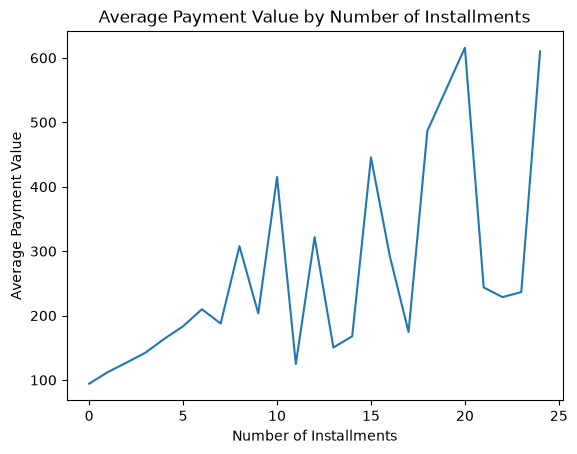

In [27]:
# chat
plt.plot(
    installment_analysis["payment_installments"],
    installment_analysis["payment_value"]
)

plt.title("Average Payment Value by Number of Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Average Payment Value")
plt.show()

Here you are analyzing two variables together:

payment_installments
        and 
payment_value

# 3. Multivariate Analysis.

Multivariate analysis means analyzing three or more variables together.

### Question 1: How do payment type and installment count affect payment value?

In [ ]:
multi_analysis = (
    payments
    .groupby(["payment_type", "payment_installments"])["payment_value"] # use here three variable
    .mean()
    .reset_index()
)

multi_analysis.head(10)

,payment_type,payment_installments,payment_value
0,boleto,1,145.034435
1,credit_card,0,94.315
2,credit_card,1,95.87293
3,credit_card,2,127.22815
4,credit_card,3,142.539317
5,credit_card,4,163.97684
6,credit_card,5,183.465222
7,credit_card,6,209.849952
8,credit_card,7,187.673672
9,credit_card,8,307.737427


In [30]:
multi_analysis = (
    payments
    .groupby(["payment_type", "payment_installments"])["payment_value"]
    .mean()
    .reset_index()
)

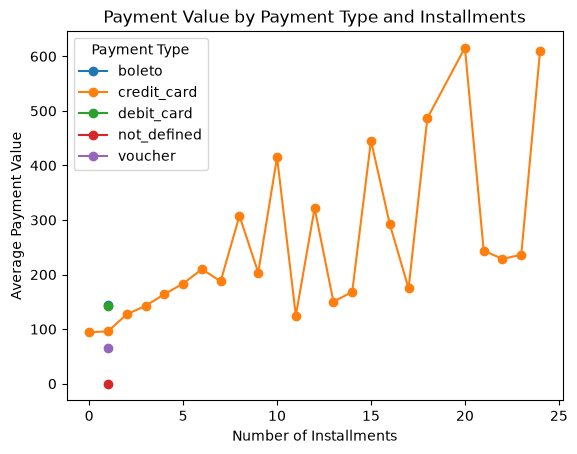

In [31]:
for payment_type in multi_analysis["payment_type"].unique():

    data = multi_analysis[
        multi_analysis["payment_type"] == payment_type
    ]

    plt.plot(
        data["payment_installments"],
        data["payment_value"],
        marker="o",
        label=payment_type
    )

plt.title("Payment Value by Payment Type and Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Average Payment Value")
plt.legend(title="Payment Type")
plt.show()


# Question 1: How do payment type and installment count affect payment value?

## 4. Trend Analysis

Analyze how business performance changes over time.

### Question 1: How does the number of orders change month by month?

In [32]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [37]:
monthly_orders = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

monthly_orders.head()

order_purchase_timestamp
2016-09-30      4
2016-10-31    324
2016-11-30      0
2016-12-31      1
2017-01-31    800
Freq: ME, dtype: int64

trend chart:

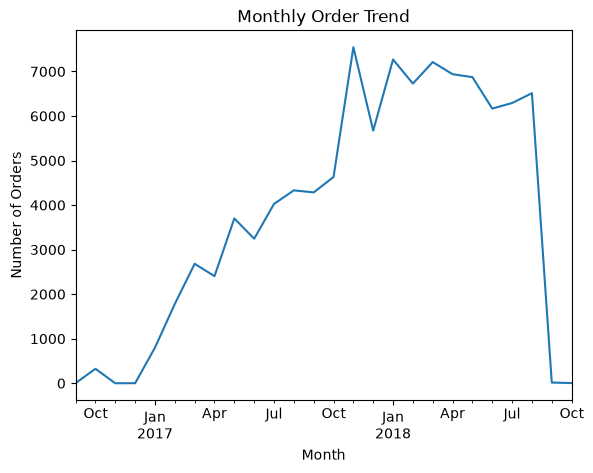

In [38]:
monthly_orders.plot()

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

# 5. Correlation Analysis.


 Analyze the relationship between numerical variables.

### Question 1: Is there a relationship between product price and freight value?

order_items from SQL into Python:

In [39]:
cursor_mysql.execute("SELECT * FROM order_items;")

rows = cursor_mysql.fetchall()
columns = [col[0] for col in cursor_mysql.description]

order_items = pd.DataFrame(rows, columns=columns)

In [40]:
# check the correlation:
order_items[
    ["price", "freight_value"]
].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


# create a heatmap. First import Seaborn:

In [42]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [43]:
import seaborn as sns

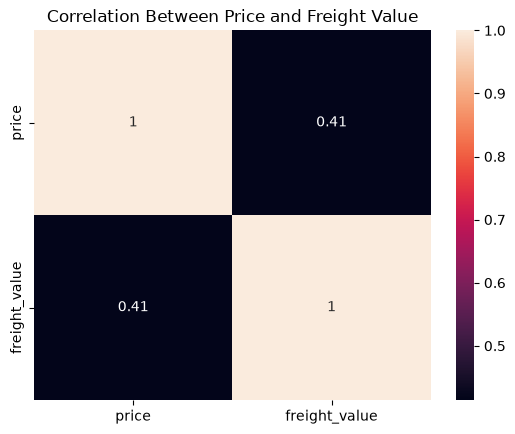

In [44]:
correlation = order_items[
    ["price", "freight_value"]
].corr()

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Between Price and Freight Value")
plt.show()

## 6. Distribution Analysis

Analyze how numerical values are spread across the dataset.

### Question 1: What is the distribution of payment values?

create a histogram:

In [ ]:
plt.hist(
    payments["payment_value"],
    bins=30
)

plt.title("Distribution of Payment Values")
plt.xlabel("Payment Value")
plt.ylabel("Frequency")
plt.show()